In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import numpy as np
from sklearn.model_selection import train_test_split

x = np.load('/content/drive/MyDrive/alphabet/images_original.npy')
y = np.load('/content/drive/MyDrive/alphabet/encoded_labels_original.npy')

# لو الصور رمادية، نضيف قناة واحدة
if len(x.shape) == 3:
    x = np.expand_dims(x, axis=-1)

x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

input_shape = x.shape[1:]
num_classes = len(np.unique(y))


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def build_cnn():
    model = Sequential([

        # --- Block 1 ---
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Block 2 ---
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Block 3 ---
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Block 4 ---
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Block 5 ---
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Dense Layers ---
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=Adam(1e-4),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model



--- Run 1 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
534/534 - 45s - 84ms/step - accuracy: 0.6209 - loss: 1.3038 - val_accuracy: 0.6050 - val_loss: 1.2605
Epoch 2/20
534/534 - 20s - 37ms/step - accuracy: 0.9484 - loss: 0.1769 - val_accuracy: 0.9844 - val_loss: 0.0598
Epoch 3/20
534/534 - 21s - 39ms/step - accuracy: 0.9802 - loss: 0.0696 - val_accuracy: 0.9870 - val_loss: 0.0473
Epoch 4/20
534/534 - 20s - 38ms/step - accuracy: 0.9845 - loss: 0.0515 - val_accuracy: 0.9902 - val_loss: 0.0434
Epoch 5/20
534/534 - 21s - 39ms/step - accuracy: 0.9888 - loss: 0.0398 - val_accuracy: 0.9884 - val_loss: 0.0431
Epoch 6/20
534/534 - 41s - 77ms/step - accuracy: 0.9898 - loss: 0.0363 - val_accuracy: 0.9898 - val_loss: 0.0353
Epoch 7/20
534/534 - 21s - 39ms/step - accuracy: 0.9876 - loss: 0.0395 - val_accuracy: 0.9891 - val_loss: 0.0445
Epoch 8/20
534/534 - 22s - 41ms/step - accuracy: 0.9884 - loss: 0.0380 - val_accuracy: 0.9875 - val_loss: 0.0387
Epoch 9/20
534/534 - 41s - 77ms/step - accuracy: 0.9907 - loss: 0.0307 - val_accuracy: 0.9898 - 

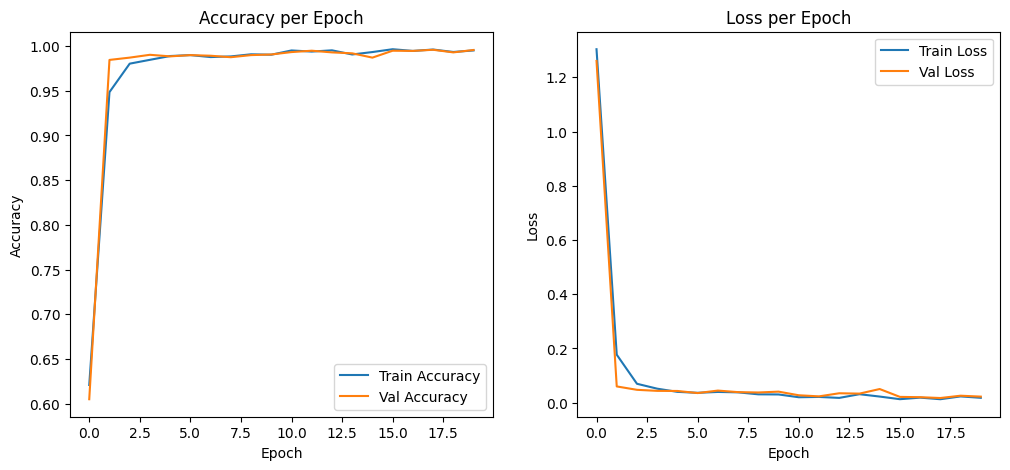

267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


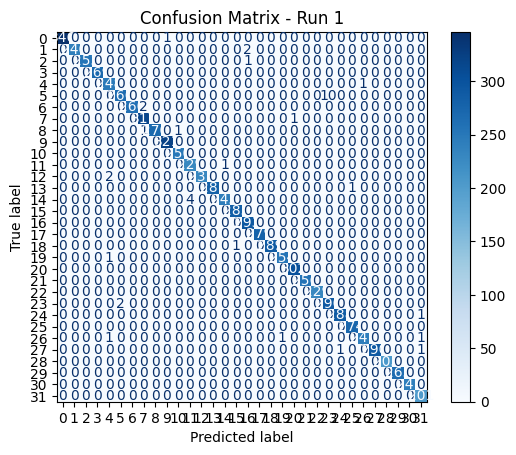

Matthews Correlation Coefficient (MCC): 0.9954
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
ROC AUC Score (macro, OvR): 1.0000

--- Run 2 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
534/534 - 41s - 77ms/step - accuracy: 0.6425 - loss: 1.2594 - val_accuracy: 0.6520 - val_loss: 1.0582
Epoch 2/20
534/534 - 27s - 50ms/step - accuracy: 0.9564 - loss: 0.1504 - val_accuracy: 0.9810 - val_loss: 0.0677
Epoch 3/20
534/534 - 21s - 38ms/step - accuracy: 0.9798 - loss: 0.0719 - val_accuracy: 0.9910 - val_loss: 0.0360
Epoch 4/20
534/534 - 21s - 39ms/step - accuracy: 0.9861 - loss: 0.0481 - val_accuracy: 0.9898 - val_loss: 0.0377
Epoch 5/20
534/534 - 41s - 76ms/step - accuracy: 0.9876 - loss: 0.0428 - val_accuracy: 0.9813 - val_loss: 0.0647
Epoch 6/20
534/534 - 22s - 41ms/step - accuracy: 0.9890 - loss: 0.0378 - val_accuracy: 0.9922 - val_loss: 0.0288
Epoch 7/20
534/534 - 21s - 40ms/step - accuracy: 0.9903 - loss: 0.0326 - val_accuracy: 0.9922 - val_loss: 0.0278
Epoch 8/20
534/534 - 21s - 39ms/step - accuracy: 0.9914 - loss: 0.0295 - val_accuracy: 0.9863 - val_loss: 0.0455
Epoch 9/20
534/534 - 22s - 41ms/step - accuracy: 0.9887 - loss: 0.0357 - val_accuracy: 0.9916 - 

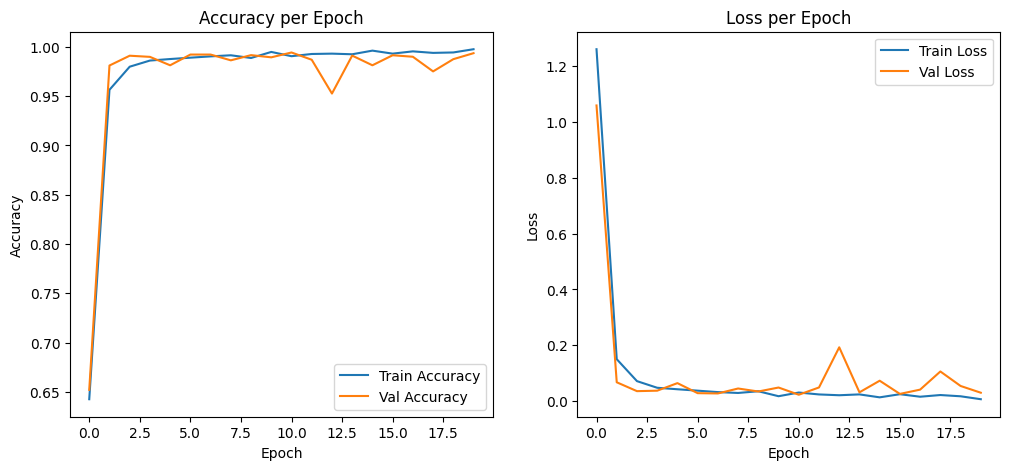

267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


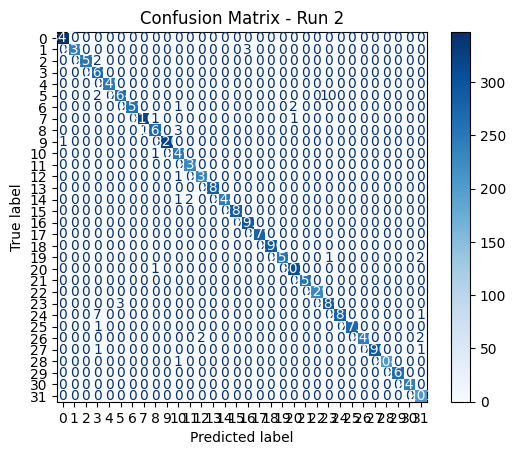

Matthews Correlation Coefficient (MCC): 0.9934
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
ROC AUC Score (macro, OvR): 1.0000

--- Run 3 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
534/534 - 45s - 84ms/step - accuracy: 0.6333 - loss: 1.2671 - val_accuracy: 0.6268 - val_loss: 1.1650
Epoch 2/20
534/534 - 23s - 43ms/step - accuracy: 0.9496 - loss: 0.1684 - val_accuracy: 0.9822 - val_loss: 0.0723
Epoch 3/20
534/534 - 41s - 77ms/step - accuracy: 0.9809 - loss: 0.0680 - val_accuracy: 0.9881 - val_loss: 0.0415
Epoch 4/20
534/534 - 42s - 79ms/step - accuracy: 0.9874 - loss: 0.0447 - val_accuracy: 0.9895 - val_loss: 0.0361
Epoch 5/20
534/534 - 22s - 41ms/step - accuracy: 0.9877 - loss: 0.0418 - val_accuracy: 0.9891 - val_loss: 0.0424
Epoch 6/20
534/534 - 22s - 41ms/step - accuracy: 0.9875 - loss: 0.0431 - val_accuracy: 0.9898 - val_loss: 0.0358
Epoch 7/20
534/534 - 41s - 77ms/step - accuracy: 0.9894 - loss: 0.0358 - val_accuracy: 0.9838 - val_loss: 0.0539
Epoch 8/20
534/534 - 40s - 75ms/step - accuracy: 0.9901 - loss: 0.0330 - val_accuracy: 0.9890 - val_loss: 0.0386
Epoch 9/20
534/534 - 21s - 39ms/step - accuracy: 0.9916 - loss: 0.0266 - val_accuracy: 0.9908 - 

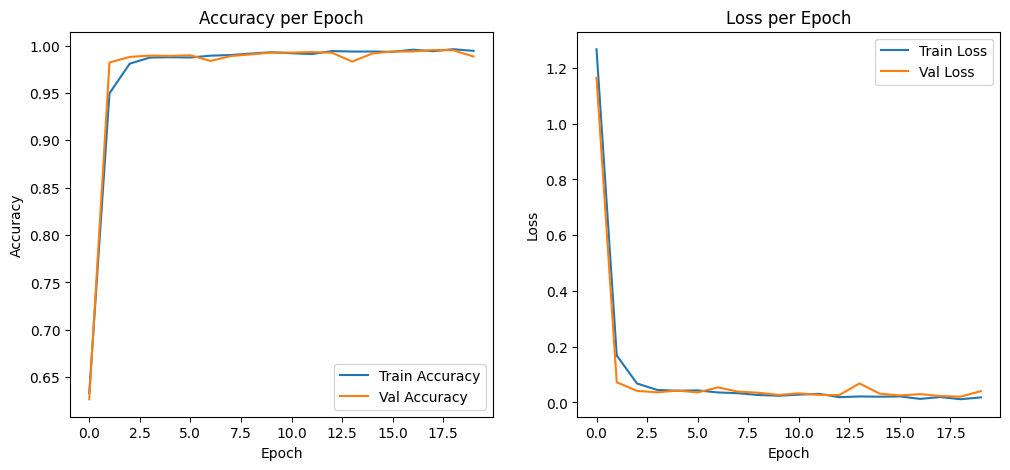

267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


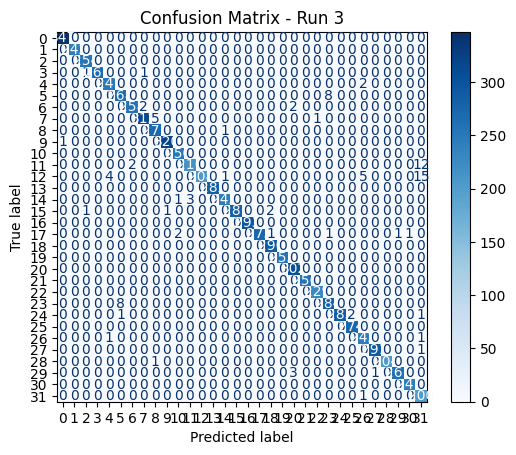

Matthews Correlation Coefficient (MCC): 0.9882
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
ROC AUC Score (macro, OvR): 0.9999

--- Run 4 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
534/534 - 44s - 83ms/step - accuracy: 0.6199 - loss: 1.3260 - val_accuracy: 0.7439 - val_loss: 0.7899
Epoch 2/20
534/534 - 25s - 46ms/step - accuracy: 0.9521 - loss: 0.1654 - val_accuracy: 0.9778 - val_loss: 0.0817
Epoch 3/20
534/534 - 40s - 75ms/step - accuracy: 0.9781 - loss: 0.0783 - val_accuracy: 0.9899 - val_loss: 0.0461
Epoch 4/20
534/534 - 21s - 40ms/step - accuracy: 0.9858 - loss: 0.0501 - val_accuracy: 0.9897 - val_loss: 0.0424
Epoch 5/20
534/534 - 40s - 75ms/step - accuracy: 0.9876 - loss: 0.0423 - val_accuracy: 0.9867 - val_loss: 0.0495
Epoch 6/20
534/534 - 21s - 40ms/step - accuracy: 0.9886 - loss: 0.0385 - val_accuracy: 0.9882 - val_loss: 0.0430
Epoch 7/20
534/534 - 41s - 78ms/step - accuracy: 0.9884 - loss: 0.0382 - val_accuracy: 0.9923 - val_loss: 0.0352
Epoch 8/20
534/534 - 41s - 77ms/step - accuracy: 0.9892 - loss: 0.0349 - val_accuracy: 0.9889 - val_loss: 0.0389
Epoch 9/20
534/534 - 40s - 74ms/step - accuracy: 0.9928 - loss: 0.0233 - val_accuracy: 0.9912 - 

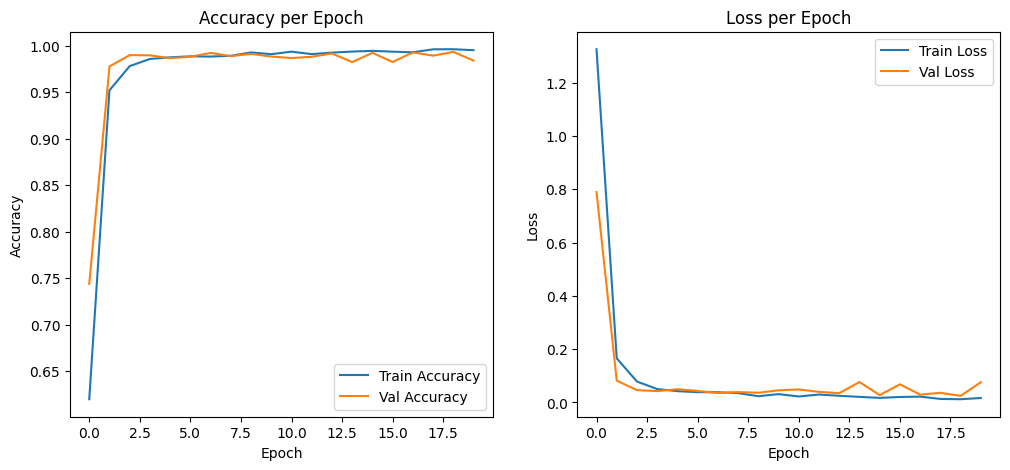

267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


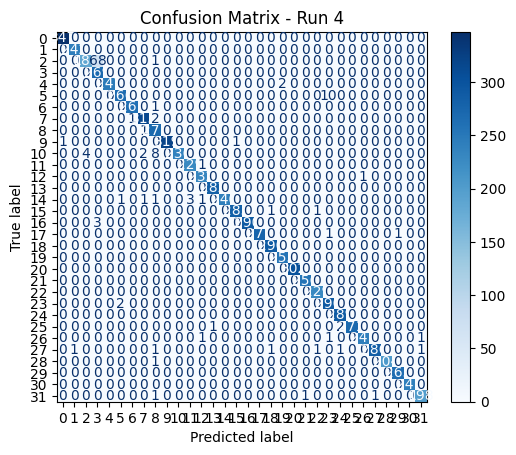

Matthews Correlation Coefficient (MCC): 0.9836
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
ROC AUC Score (macro, OvR): 0.9999

--- Run 5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
534/534 - 41s - 77ms/step - accuracy: 0.6197 - loss: 1.3483 - val_accuracy: 0.6403 - val_loss: 1.1181
Epoch 2/20
534/534 - 22s - 42ms/step - accuracy: 0.9480 - loss: 0.1773 - val_accuracy: 0.9863 - val_loss: 0.0582
Epoch 3/20
534/534 - 22s - 41ms/step - accuracy: 0.9797 - loss: 0.0726 - val_accuracy: 0.9878 - val_loss: 0.0490
Epoch 4/20
534/534 - 40s - 74ms/step - accuracy: 0.9857 - loss: 0.0520 - val_accuracy: 0.9897 - val_loss: 0.0374
Epoch 5/20
534/534 - 21s - 40ms/step - accuracy: 0.9892 - loss: 0.0393 - val_accuracy: 0.9807 - val_loss: 0.0629
Epoch 6/20
534/534 - 42s - 78ms/step - accuracy: 0.9868 - loss: 0.0457 - val_accuracy: 0.9879 - val_loss: 0.0420
Epoch 7/20
534/534 - 22s - 42ms/step - accuracy: 0.9889 - loss: 0.0365 - val_accuracy: 0.9739 - val_loss: 0.0904
Epoch 8/20
534/534 - 39s - 74ms/step - accuracy: 0.9902 - loss: 0.0345 - val_accuracy: 0.9874 - val_loss: 0.0475
Epoch 9/20
534/534 - 21s - 40ms/step - accuracy: 0.9899 - loss: 0.0348 - val_accuracy: 0.9915 - 

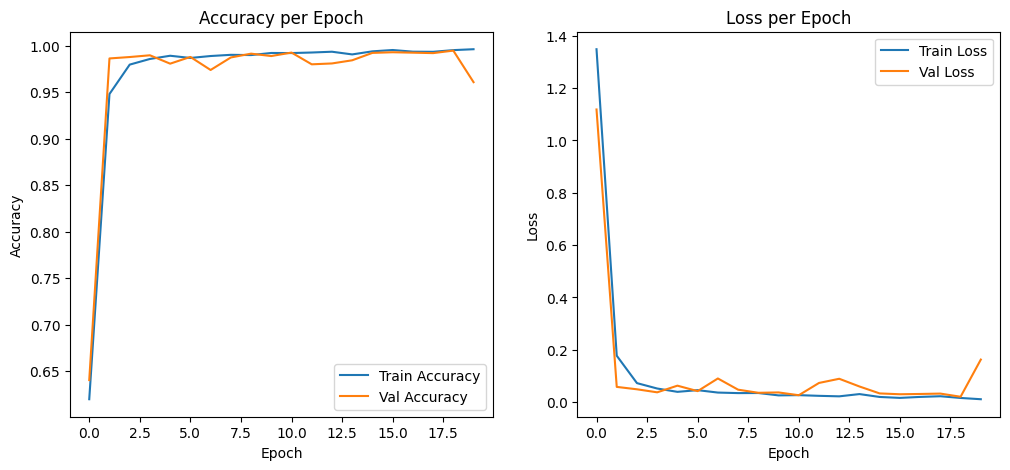

267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


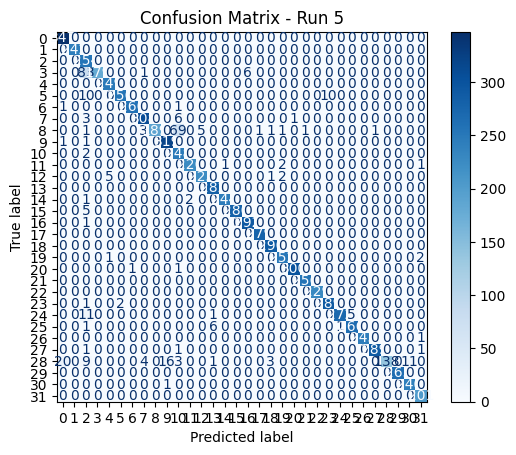

Matthews Correlation Coefficient (MCC): 0.9598
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
ROC AUC Score (macro, OvR): 0.9998

--- Run 6 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
534/534 - 42s - 78ms/step - accuracy: 0.6417 - loss: 1.2608 - val_accuracy: 0.7171 - val_loss: 0.8575
Epoch 2/20
534/534 - 21s - 40ms/step - accuracy: 0.9546 - loss: 0.1534 - val_accuracy: 0.9796 - val_loss: 0.0764
Epoch 3/20
534/534 - 41s - 76ms/step - accuracy: 0.9795 - loss: 0.0707 - val_accuracy: 0.9883 - val_loss: 0.0434
Epoch 4/20
534/534 - 41s - 77ms/step - accuracy: 0.9852 - loss: 0.0499 - val_accuracy: 0.9875 - val_loss: 0.0470
Epoch 5/20
534/534 - 21s - 39ms/step - accuracy: 0.9881 - loss: 0.0425 - val_accuracy: 0.9905 - val_loss: 0.0390
Epoch 6/20
534/534 - 22s - 41ms/step - accuracy: 0.9906 - loss: 0.0341 - val_accuracy: 0.9895 - val_loss: 0.0425
Epoch 7/20
534/534 - 21s - 38ms/step - accuracy: 0.9883 - loss: 0.0400 - val_accuracy: 0.9879 - val_loss: 0.0411
Epoch 8/20
534/534 - 41s - 77ms/step - accuracy: 0.9898 - loss: 0.0350 - val_accuracy: 0.9767 - val_loss: 0.0771
Epoch 9/20
534/534 - 42s - 79ms/step - accuracy: 0.9901 - loss: 0.0303 - val_accuracy: 0.9913 - 

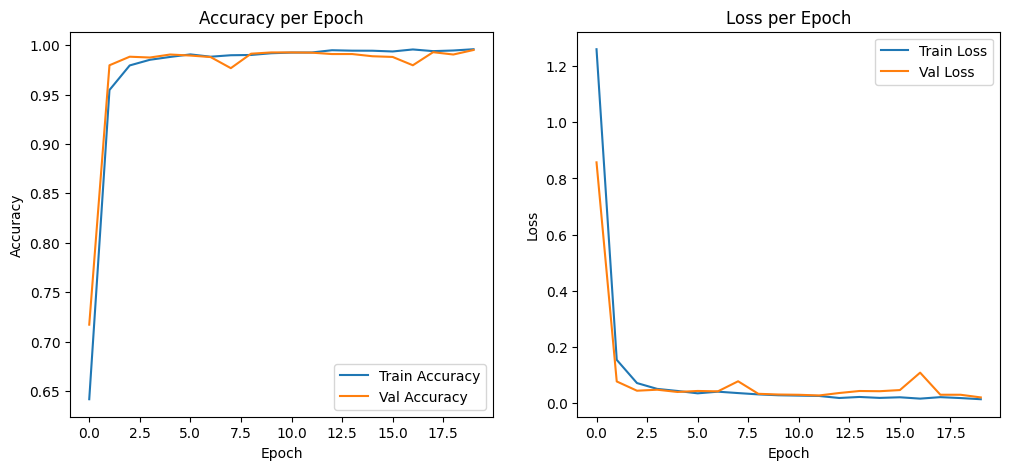

267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


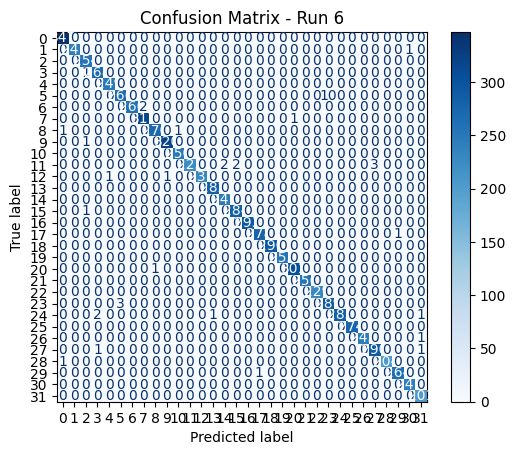

Matthews Correlation Coefficient (MCC): 0.9949
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
ROC AUC Score (macro, OvR): 1.0000

--- Run 7 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
534/534 - 47s - 87ms/step - accuracy: 0.6320 - loss: 1.2800 - val_accuracy: 0.6527 - val_loss: 1.0620
Epoch 2/20
534/534 - 23s - 43ms/step - accuracy: 0.9515 - loss: 0.1659 - val_accuracy: 0.9840 - val_loss: 0.0620
Epoch 3/20
534/534 - 42s - 79ms/step - accuracy: 0.9810 - loss: 0.0676 - val_accuracy: 0.9853 - val_loss: 0.0565
Epoch 4/20
534/534 - 40s - 75ms/step - accuracy: 0.9859 - loss: 0.0484 - val_accuracy: 0.9884 - val_loss: 0.0380
Epoch 5/20
534/534 - 42s - 79ms/step - accuracy: 0.9871 - loss: 0.0433 - val_accuracy: 0.9905 - val_loss: 0.0375
Epoch 6/20
534/534 - 21s - 40ms/step - accuracy: 0.9872 - loss: 0.0408 - val_accuracy: 0.9849 - val_loss: 0.0535
Epoch 7/20
534/534 - 21s - 39ms/step - accuracy: 0.9897 - loss: 0.0350 - val_accuracy: 0.9885 - val_loss: 0.0459
Epoch 8/20
534/534 - 42s - 79ms/step - accuracy: 0.9929 - loss: 0.0248 - val_accuracy: 0.9858 - val_loss: 0.0537
Epoch 9/20
534/534 - 41s - 77ms/step - accuracy: 0.9903 - loss: 0.0336 - val_accuracy: 0.9871 - 

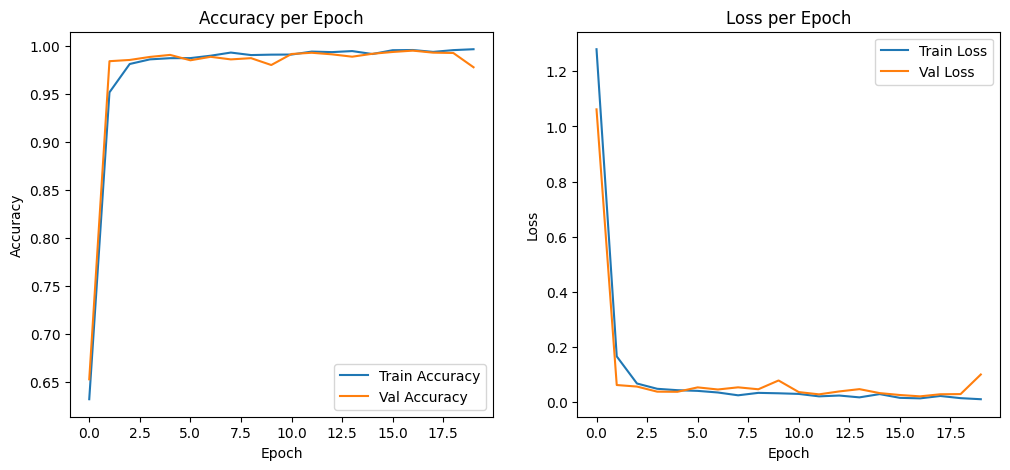

267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


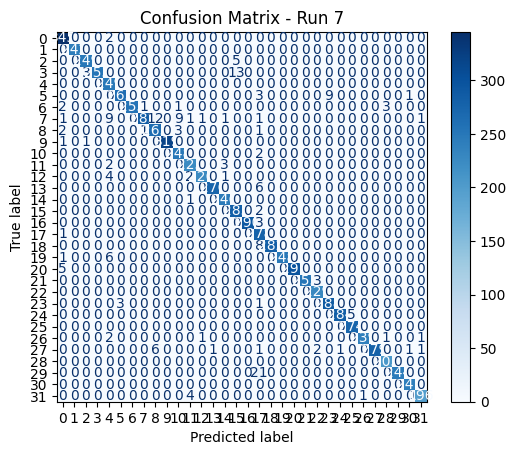

Matthews Correlation Coefficient (MCC): 0.9770
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
ROC AUC Score (macro, OvR): 0.9998

--- Run 8 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
534/534 - 41s - 78ms/step - accuracy: 0.6210 - loss: 1.3205 - val_accuracy: 0.5885 - val_loss: 1.3279
Epoch 2/20
534/534 - 21s - 39ms/step - accuracy: 0.9484 - loss: 0.1733 - val_accuracy: 0.9815 - val_loss: 0.0638
Epoch 3/20
534/534 - 41s - 76ms/step - accuracy: 0.9792 - loss: 0.0733 - val_accuracy: 0.9904 - val_loss: 0.0453
Epoch 4/20
534/534 - 43s - 80ms/step - accuracy: 0.9865 - loss: 0.0466 - val_accuracy: 0.9867 - val_loss: 0.0483
Epoch 5/20
534/534 - 22s - 41ms/step - accuracy: 0.9868 - loss: 0.0463 - val_accuracy: 0.9892 - val_loss: 0.0445
Epoch 6/20
534/534 - 41s - 76ms/step - accuracy: 0.9876 - loss: 0.0414 - val_accuracy: 0.9897 - val_loss: 0.0433
Epoch 7/20
534/534 - 21s - 40ms/step - accuracy: 0.9908 - loss: 0.0325 - val_accuracy: 0.9918 - val_loss: 0.0328
Epoch 8/20
534/534 - 22s - 41ms/step - accuracy: 0.9912 - loss: 0.0291 - val_accuracy: 0.9828 - val_loss: 0.0616
Epoch 9/20
534/534 - 40s - 74ms/step - accuracy: 0.9914 - loss: 0.0289 - val_accuracy: 0.9863 - 

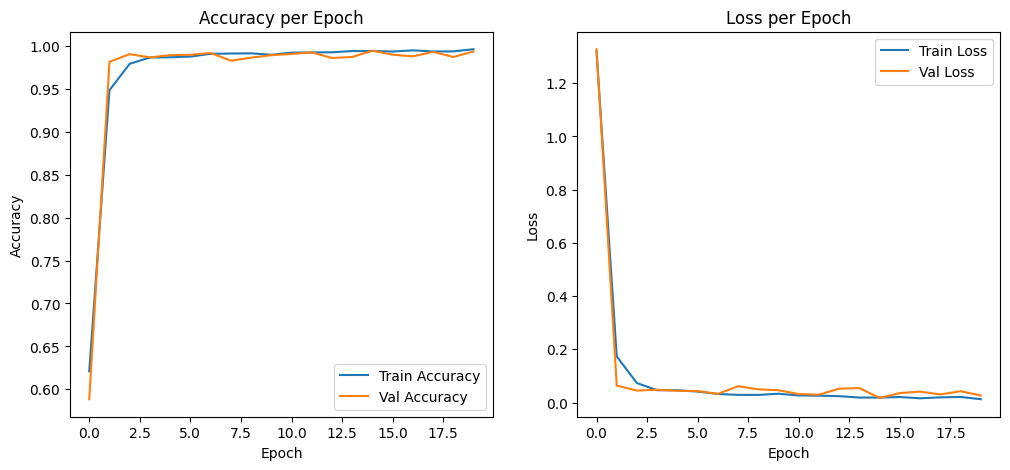

267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


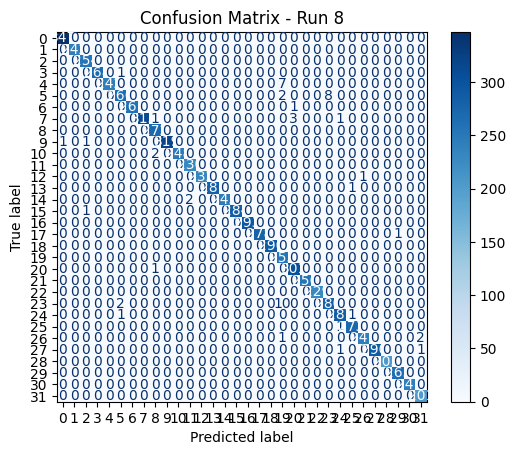

Matthews Correlation Coefficient (MCC): 0.9934
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
ROC AUC Score (macro, OvR): 0.9999

--- Run 9 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
534/534 - 41s - 78ms/step - accuracy: 0.6114 - loss: 1.3513 - val_accuracy: 0.6282 - val_loss: 1.1421
Epoch 2/20
534/534 - 21s - 39ms/step - accuracy: 0.9443 - loss: 0.1848 - val_accuracy: 0.9837 - val_loss: 0.0701
Epoch 3/20
534/534 - 41s - 77ms/step - accuracy: 0.9796 - loss: 0.0718 - val_accuracy: 0.9901 - val_loss: 0.0417
Epoch 4/20
534/534 - 41s - 77ms/step - accuracy: 0.9859 - loss: 0.0479 - val_accuracy: 0.9869 - val_loss: 0.0452
Epoch 5/20
534/534 - 40s - 76ms/step - accuracy: 0.9873 - loss: 0.0429 - val_accuracy: 0.9901 - val_loss: 0.0459
Epoch 6/20
534/534 - 41s - 77ms/step - accuracy: 0.9901 - loss: 0.0332 - val_accuracy: 0.9871 - val_loss: 0.0479
Epoch 7/20
534/534 - 21s - 39ms/step - accuracy: 0.9865 - loss: 0.0437 - val_accuracy: 0.9870 - val_loss: 0.0492
Epoch 8/20
534/534 - 41s - 76ms/step - accuracy: 0.9906 - loss: 0.0314 - val_accuracy: 0.9843 - val_loss: 0.0557
Epoch 9/20
534/534 - 41s - 78ms/step - accuracy: 0.9893 - loss: 0.0349 - val_accuracy: 0.9878 - 

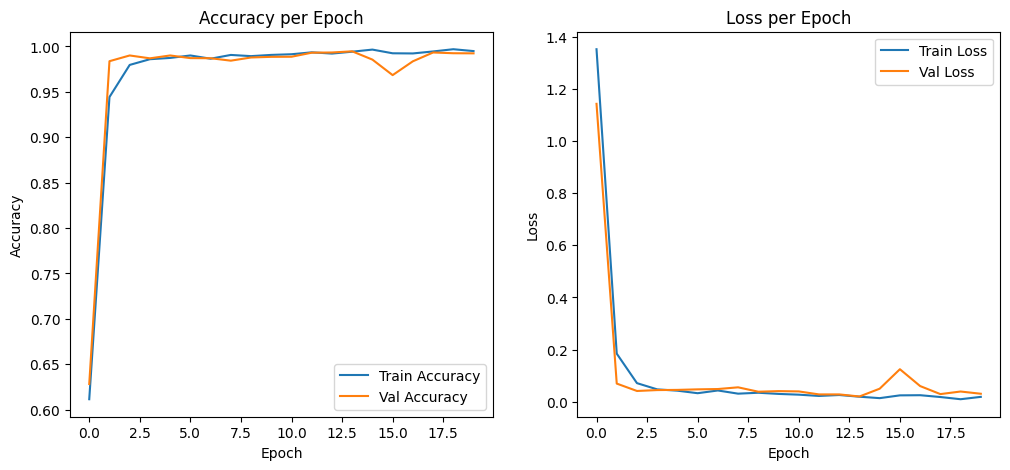

267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


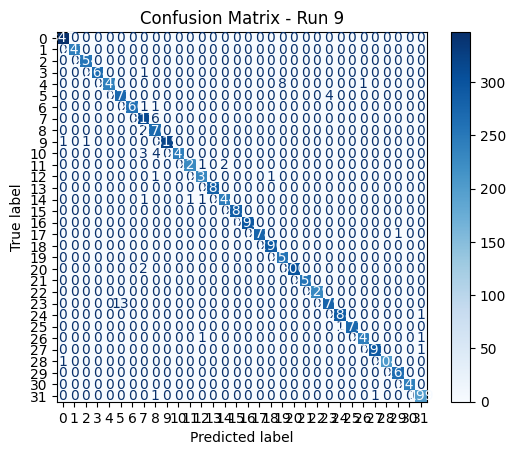

Matthews Correlation Coefficient (MCC): 0.9921
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
ROC AUC Score (macro, OvR): 1.0000

--- Run 10 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
534/534 - 43s - 81ms/step - accuracy: 0.6241 - loss: 1.3108 - val_accuracy: 0.7115 - val_loss: 0.9234
Epoch 2/20
534/534 - 21s - 39ms/step - accuracy: 0.9527 - loss: 0.1653 - val_accuracy: 0.9807 - val_loss: 0.0698
Epoch 3/20
534/534 - 41s - 77ms/step - accuracy: 0.9808 - loss: 0.0684 - val_accuracy: 0.9895 - val_loss: 0.0420
Epoch 4/20
534/534 - 42s - 79ms/step - accuracy: 0.9865 - loss: 0.0493 - val_accuracy: 0.9874 - val_loss: 0.0426
Epoch 5/20
534/534 - 21s - 39ms/step - accuracy: 0.9886 - loss: 0.0415 - val_accuracy: 0.9806 - val_loss: 0.0679
Epoch 6/20
534/534 - 21s - 39ms/step - accuracy: 0.9864 - loss: 0.0441 - val_accuracy: 0.9871 - val_loss: 0.0498
Epoch 7/20
534/534 - 41s - 77ms/step - accuracy: 0.9903 - loss: 0.0325 - val_accuracy: 0.9867 - val_loss: 0.0455
Epoch 8/20
534/534 - 21s - 40ms/step - accuracy: 0.9905 - loss: 0.0333 - val_accuracy: 0.9895 - val_loss: 0.0361
Epoch 9/20
534/534 - 40s - 76ms/step - accuracy: 0.9910 - loss: 0.0300 - val_accuracy: 0.9899 - 

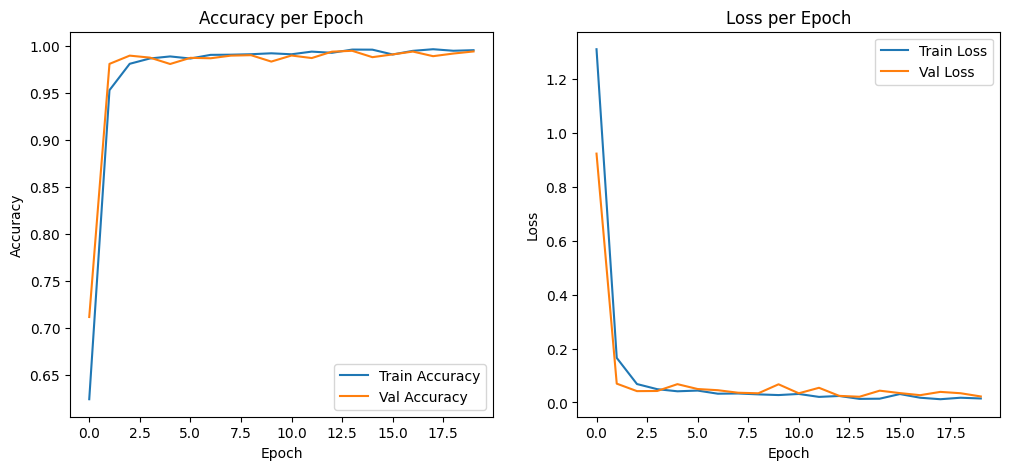

267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


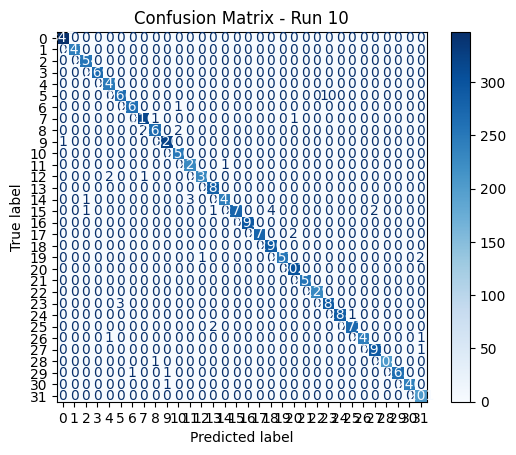

Matthews Correlation Coefficient (MCC): 0.9937
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
ROC AUC Score (macro, OvR): 1.0000


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, matthews_corrcoef, roc_auc_score
from sklearn.preprocessing import label_binarize
import pandas as pd

num_runs = 10
results = []

for run in range(1, num_runs+1):
    print(f"\n--- Run {run} ---")
    model = build_cnn()
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=20,
        batch_size=64,
        verbose=2
    )

    val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)
    print(f"Run {run} - Validation Accuracy: {val_acc:.4f} | Validation Loss: {val_loss:.4f}")

    # --- رسم Accuracy و Loss لكل Epoch ---
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # --- Confusion Matrix ---
    y_pred = np.argmax(model.predict(x_val), axis=1)
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - Run {run}")
    plt.show()

    # --- MCC ---
    mcc = matthews_corrcoef(y_val, y_pred)
    print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

    # --- ROC AUC ---
    y_val_bin = label_binarize(y_val, classes=np.arange(num_classes))
    y_pred_prob = model.predict(x_val)
    roc_auc = roc_auc_score(y_val_bin, y_pred_prob, average='macro', multi_class='ovr')
    print(f"ROC AUC Score (macro, OvR): {roc_auc:.4f}")

    results.append({'Run': run, 'Val_Accuracy': val_acc, 'Val_Loss': val_loss, 'MCC': mcc, 'ROC_AUC': roc_auc})


In [13]:
df_results = pd.DataFrame(results)
df_results.to_excel('/content/drive/MyDrive/alphabet/CNN_runs_analysis_Original.xlsx', index=False)
print("✅ Results saved to CNN_runs_analysis.xlsx")
print(df_results)


✅ Results saved to CNN_runs_analysis.xlsx
   Run  Val_Accuracy  Val_Loss       MCC   ROC_AUC
0    1      0.995552  0.022218  0.995408  0.999957
1    2      0.993563  0.030376  0.993356  0.999974
2    3      0.988530  0.040428  0.988167  0.999935
3    4      0.984082  0.075771  0.983631  0.999919
4    5      0.960791  0.162555  0.959807  0.999767
5    6      0.995084  0.019486  0.994925  0.999988
6    7      0.977645  0.100276  0.976956  0.999783
7    8      0.993563  0.026924  0.993356  0.999949
8    9      0.992392  0.031098  0.992147  0.999953
9   10      0.993914  0.022272  0.993717  0.999972



📊 Average Results across all runs:
Average Accuracy : 0.9875
Average Loss     : 0.0531
Average MCC      : 0.9871
Average ROC AUC  : 0.9999

✅ Results saved to /content/drive/MyDrive/alphabet/CNN_runs_results_Original.xlsx


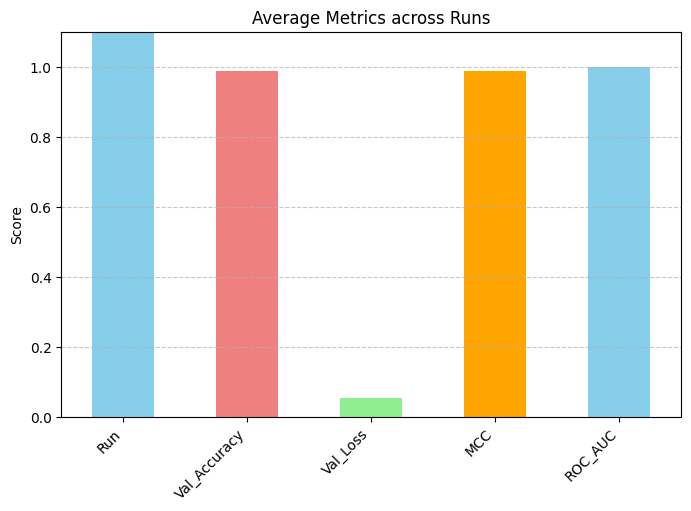

In [15]:
import matplotlib.pyplot as plt

# --- تحويل النتائج ل DataFrame ---
results_df = pd.DataFrame(results)

# --- حساب المتوسط لكل مقياس ---
avg_results = results_df.mean(numeric_only=True)

print("\n📊 Average Results across all runs:")
print(f"Average Accuracy : {avg_results['Val_Accuracy']:.4f}")
print(f"Average Loss     : {avg_results['Val_Loss']:.4f}")
print(f"Average MCC      : {avg_results['MCC']:.4f}")
print(f"Average ROC AUC  : {avg_results['ROC_AUC']:.4f}")

# --- حفظ النتائج في Excel ---
save_path = "/content/drive/MyDrive/alphabet/CNN_runs_results_Original.xlsx"
with pd.ExcelWriter(save_path) as writer:
    results_df.to_excel(writer, sheet_name="All Runs", index=False)
    avg_results.to_frame(name="Average").to_excel(writer, sheet_name="Average")

print(f"\n✅ Results saved to {save_path}")

# --- رسم المتوسطات ---
plt.figure(figsize=(8,5))
avg_results.plot(kind='bar', color=['skyblue','lightcoral','lightgreen','orange'])
plt.title("Average Metrics across Runs")
plt.ylabel("Score")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1)  # معظم المقاييس بتبقى بين 0 و 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


📐 Input Shape: 64x64x1


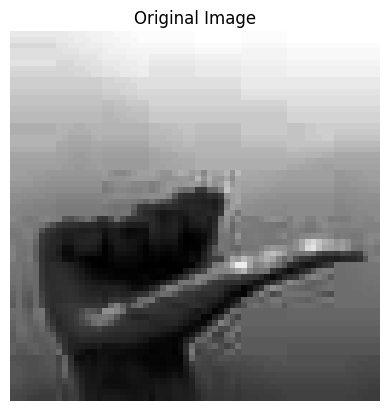

Predicted class: dhad (1.00)


  0%|          | 0/1000 [00:00<?, ?it/s]

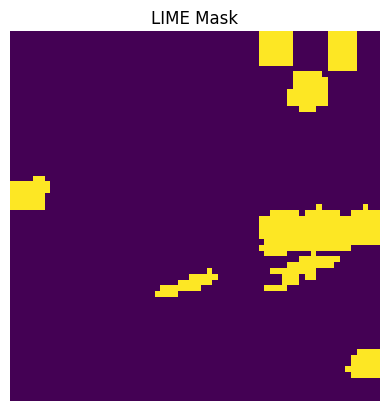

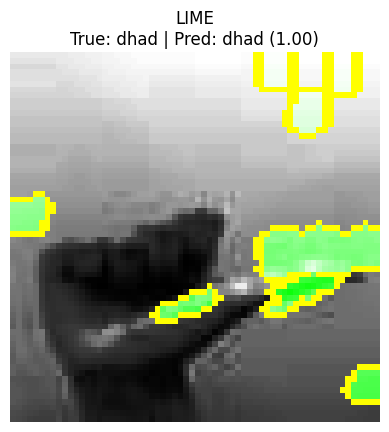

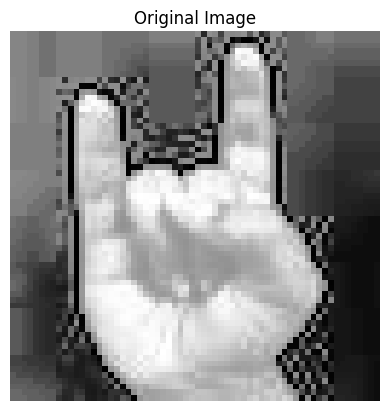

Predicted class: la (1.00)


  0%|          | 0/1000 [00:00<?, ?it/s]

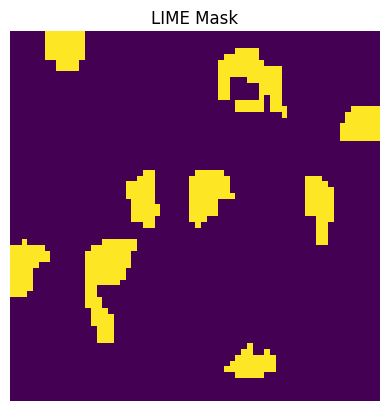

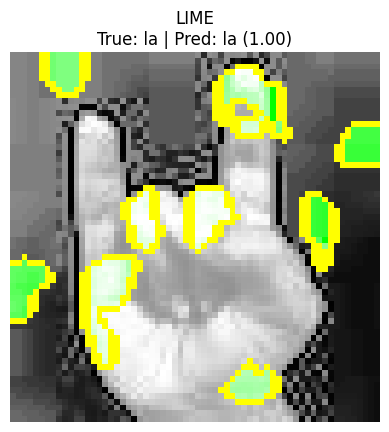

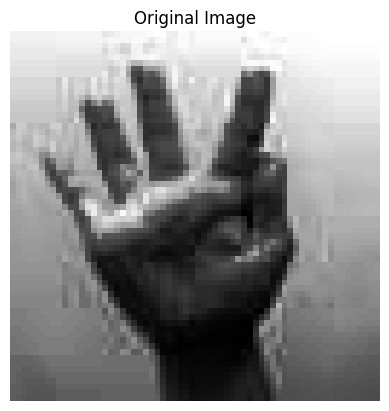

Predicted class: sheen (1.00)


  0%|          | 0/1000 [00:00<?, ?it/s]

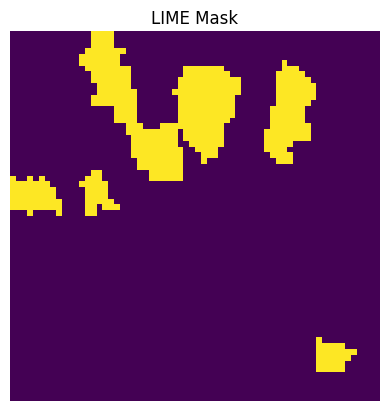

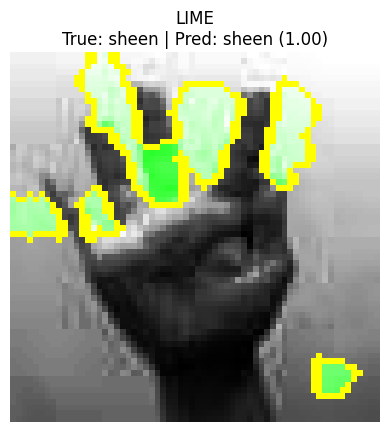

In [16]:
!pip install lime
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
from skimage.transform import resize

# تحميل أسماء الكلاسات
class_names = np.load('/content/drive/MyDrive/alphabet/label_encoder_classes.npy', allow_pickle=True)

# استخراج شكل مدخلات الموديل
H, W, C = model.input_shape[1:]
print(f"📐 Input Shape: {H}x{W}x{C}")

# دالة تجهيز الصور زي التدريب
def preprocess_batch(images):
    out = []
    for im in images:
        im = np.asarray(im)
        if im.ndim == 2:  # صورة رمادية
            im = np.repeat(im[..., np.newaxis], 3, axis=-1)
            im = np.squeeze(im)
        elif im.shape[-1] == 1 and C == 3:
            im = np.repeat(im, 3, axis=-1)
            im = np.squeeze(im)
        # تغيير الحجم لتوافق مدخلات الموديل
        im = resize(im, (H, W, C), preserve_range=True, anti_aliasing=True).astype('float32')
        if im.max() > 1.0:
            im = im / 255.0
        out.append(im)
    return np.asarray(out, dtype='float32')

# دالة التنبؤ لـ LIME
def predict_fn(images):
    Xb = preprocess_batch(images)
    return model.predict(Xb, verbose=0)

# إنشاء مفسر LIME
explainer = lime_image.LimeImageExplainer()

# اختيار صور عشوائية للتفسير
indices = np.random.choice(len(x_val), size=3, replace=False)

for idx in indices:
    image = x_val[idx]

    # تجهيز نسخة RGB للعرض
    if image.ndim == 2 or image.shape[-1] == 1:
        image_rgb = np.repeat(image[..., np.newaxis], 3, axis=-1)
        image_rgb = np.squeeze(image_rgb)
    else:
        image_rgb = image
    image_rgb = image_rgb[..., :3]

    # --- عرض الصورة الأصلية ---
    plt.figure()
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis('off')
    plt.show()

    # --- تنبؤ الموديل ---
    pred_probs = model.predict(preprocess_batch([image]), verbose=0)[0]
    pred_label = int(np.argmax(pred_probs))
    print(f"Predicted class: {class_names[pred_label]} ({pred_probs[pred_label]:.2f})")

    # --- تفسير LIME ---
    explanation = explainer.explain_instance(
        image_rgb.astype('double'),
        predict_fn,
        labels=[pred_label],
        hide_color=0,
        num_samples=1000,
        segmentation_fn=slic
    )

    # --- استخراج الـ mask ---
    temp, mask = explanation.get_image_and_mask(
        pred_label,
        positive_only=False,
        num_features=10,
        hide_rest=False
    )

    # --- عرض الـ mask ---
    plt.figure()
    plt.imshow(mask)
    plt.title("LIME Mask")
    plt.axis('off')
    plt.show()

    # --- عرض الصورة مع الحدود ---
    true_class_name = class_names[int(y_val[idx])]
    predicted_class_name = class_names[pred_label]
    plt.figure()
    plt.imshow(mark_boundaries(temp, mask))
    plt.title(f"LIME\nTrue: {true_class_name} | Pred: {predicted_class_name} ({pred_probs[pred_label]:.2f})")
    plt.axis('off')
    plt.show()


In [8]:
import numpy as np

# حفظ الموديل بصيغة Keras الجديدة
model.save('/content/drive/MyDrive/my_modelcnn_Original.keras')

# حفظ بيانات validation (لو محتاجة تكمل عليها)
np.save('/content/drive/MyDrive/x_val_cnn_original.npy', x_val)
np.save('/content/drive/MyDrive/y_val_cnn_original.npy', y_val)
